<a href="https://colab.research.google.com/github/Foysal061/EmergencyDepartmentPatientPred/blob/main/BiDirectional_Lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#pip install openmeteo-requests requests-cache retry-requests numpy pandas tensorflow scikit-learn
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler,RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from datetime import datetime, timedelta
import openmeteo_requests
import requests_cache
from retry_requests import retry
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Rectangle
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# File paths (MODIFY THESE FOR YOUR SETUP)
ED_DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/VestfoldTriageReport.csv"
INFECTION_DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/Infeksjonsdata.xlsx"

# Hospital coordinates (Vestfold Hospital, Tønsberg)
HOSPITAL_LAT = 59.2725
HOSPITAL_LON = 10.4184

# Feature engineering
USE_LAG_FEATURES = True

LOOKBACK = 24  # Hours to look back for LSTM

In [3]:
def load_ed_data(filepath, separator=';'):
    """Load ED data from CSV"""
    print("\n[1/10] Loading ED data...")
    df = pd.read_csv(filepath, sep=separator)
    df.columns = ['arrival', 'departure', 'first_doctor_response', 'first_triage']
    print(f"   Loaded {len(df)} records")
    print("\nFirst 5 rows:")
    print(df.head())
    return df

# Load data
df = load_ed_data(ED_DATA_PATH)

print("\nData shape:", df.shape)
print("Columns:", df.columns.tolist())


[1/10] Loading ED data...
   Loaded 35674 records

First 5 rows:
            arrival         departure first_doctor_response   first_triage
0  01.10.2023 13:46  06.10.2023 18:10            LessUrgent  Resuscitation
1  01.10.2023 14:20  20.10.2023 11:37            LessUrgent     LessUrgent
2  01.10.2023 13:59  03.10.2023 12:04                   NaN  Resuscitation
3  01.10.2023 14:40  01.10.2023 17:30            LessUrgent     LessUrgent
4  01.10.2023 13:50  01.10.2023 20:45             NotUrgent         Urgent

Data shape: (35674, 4)
Columns: ['arrival', 'departure', 'first_doctor_response', 'first_triage']


In [4]:
def parse_datetime_columns(df):
    """Parse and convert datetime columns"""
    print("\n[2/10] Parsing datetime fields...")

    df['arrival'] = pd.to_datetime(df['arrival'], format='%d.%m.%Y %H:%M', errors='coerce')
    df['departure'] = pd.to_datetime(df['departure'], format='%d.%m.%Y %H:%M', errors='coerce')

    df = df.dropna(subset=['arrival', 'departure'])
    df = df.sort_values('arrival')

    local_zone = 'Europe/Oslo'
    df['arrival'] = df['arrival'].dt.tz_localize(local_zone).dt.tz_convert('UTC').dt.tz_localize(None)
    df['departure'] = df['departure'].dt.tz_localize(local_zone).dt.tz_convert('UTC').dt.tz_localize(None)

    df['duration_hour'] = (df['departure'] - df['arrival']).dt.total_seconds() / (60*60)

    print(f"   Parsed {len(df)} records")
    print(f"   Date range: {df['arrival'].min()} to {df['arrival'].max()}")
    return df

df = parse_datetime_columns(df)

print("\nSample data after parsing:")
print(df.head())


[2/10] Parsing datetime fields...
   Parsed 35674 records
   Date range: 2023-10-01 11:46:00 to 2024-10-25 10:35:00

Sample data after parsing:
              arrival           departure first_doctor_response  \
0 2023-10-01 11:46:00 2023-10-06 16:10:00            LessUrgent   
4 2023-10-01 11:50:00 2023-10-01 18:45:00             NotUrgent   
7 2023-10-01 11:59:00 2023-10-05 13:05:00                Urgent   
2 2023-10-01 11:59:00 2023-10-03 10:04:00                   NaN   
8 2023-10-01 12:20:00 2023-10-02 12:01:00            LessUrgent   

    first_triage  duration_hour  
0  Resuscitation     124.400000  
4         Urgent       6.916667  
7  Resuscitation      97.100000  
2  Resuscitation      46.083333  
8  Resuscitation      23.683333  


In [5]:
def aggregate_to_hourly(df):
    """Aggregate data to hourly intervals"""
    print("\n[3/10] Aggregating to hourly intervals...")

    df['arrival_hour'] = df['arrival'].dt.floor('H')

    hourly_df = df.groupby('arrival_hour').agg({
        'arrival': 'count',
        'duration_hour': ['mean', 'std']
    })

    hourly_df.columns = ['arrival_count', 'duration_mean', 'duration_std']
    hourly_df = hourly_df.reset_index()
    hourly_df[['duration_mean', 'duration_std']] = hourly_df[['duration_mean', 'duration_std']].fillna(0)
    hourly_df['first_doctor_response'] = df['first_doctor_response'].fillna('Unknown')
    hourly_df['first_triage'] = df['first_triage'].fillna('Unknown')

    print(f"   Created {len(hourly_df)} hourly records")
    return hourly_df

df = aggregate_to_hourly(df)

print("\nHourly aggregated data:")
print(df.head(10))


[3/10] Aggregating to hourly intervals...
   Created 8284 hourly records

Hourly aggregated data:
         arrival_hour  arrival_count  duration_mean  duration_std  \
0 2023-10-01 11:00:00              4      68.625000     52.401404   
1 2023-10-01 12:00:00              6     103.847222    174.344335   
2 2023-10-01 13:00:00              6      54.219444     71.494779   
3 2023-10-01 14:00:00              3      11.183333     12.190809   
4 2023-10-01 15:00:00              6     110.741667    110.665416   
5 2023-10-01 16:00:00              3       3.961111      1.736242   
6 2023-10-01 17:00:00              2      20.550000      2.734146   
7 2023-10-01 18:00:00              5      76.573333     69.082435   
8 2023-10-01 19:00:00              4      76.704167    104.066427   
9 2023-10-01 20:00:00              2     124.100000     87.186266   

  first_doctor_response   first_triage  
0            LessUrgent  Resuscitation  
1            LessUrgent     LessUrgent  
2               Un

In [6]:
def fetch_weather_data(start_date, end_date):
    """Fetch weather data from Open-Meteo API in UTC timezone"""
    print(f"\n[4/10] Fetching weather data...")

    cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
    retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
    openmeteo = openmeteo_requests.Client(session=retry_session)

    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": HOSPITAL_LAT,
        "longitude": HOSPITAL_LON,
        "start_date": start_date,
        "end_date": end_date,
        "timezone": "UTC",  # Set timezone to UTC
        "hourly": ["temperature_2m", "relative_humidity_2m", "precipitation",
                  "surface_pressure", "wind_speed_10m"]
    }

    responses = openmeteo.weather_api(url, params=params)
    response = responses[0]
    hourly = response.Hourly()

    timestamps = pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s"),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s"),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive="left"
    )

    weather_df = pd.DataFrame({
        "date": timestamps,
        "temperature": hourly.Variables(0).ValuesAsNumpy().astype(float).round(2),
        "humidity": hourly.Variables(1).ValuesAsNumpy().astype(float).round(2),
        "precipitation": hourly.Variables(2).ValuesAsNumpy().astype(float).round(2),
        "pressure": hourly.Variables(3).ValuesAsNumpy().astype(float).round(2),
        "wind_speed": hourly.Variables(4).ValuesAsNumpy().astype(float).round(2)
    })

    weather_df['date'] = pd.to_datetime(weather_df['date']).dt.tz_localize(None)
    print(f"   Fetched {len(weather_df)} weather records")
    print(f"   Timezone: UTC")
    return weather_df

# Fetch weather data (adjust dates based on your data)
weather_df = fetch_weather_data("2023-01-10", "2024-10-26")

print("\nWeather data sample:")
print(weather_df.head())


[4/10] Fetching weather data...
   Fetched 15744 weather records
   Timezone: UTC

Weather data sample:
                 date  temperature  humidity  precipitation  pressure  \
0 2023-01-10 00:00:00         1.40     98.58            0.0    995.77   
1 2023-01-10 01:00:00         1.65     98.93            0.0    996.47   
2 2023-01-10 02:00:00         1.85     97.53            0.0    997.27   
3 2023-01-10 03:00:00         1.70     96.48            0.0    997.77   
4 2023-01-10 04:00:00         0.55     98.92            0.0    998.36   

   wind_speed  
0        6.88  
1        7.42  
2        7.93  
3        5.62  
4        3.32  


In [7]:
def merge_weather_data(df, weather_df):
    """Merge weather data with ED data"""
    print("\n[5/10] Merging weather data...")

    df['arrival_hour'] = pd.to_datetime(df['arrival_hour'])
    weather_df['date'] = pd.to_datetime(weather_df['date'])

    merged_df = pd.merge_asof(
        df.sort_values("arrival_hour"),
        weather_df.sort_values("date"),
        left_on="arrival_hour",
        right_on="date",
        direction="nearest"
    )

    merged_df = merged_df.drop(columns=['date'], errors='ignore')
    print(f"   Merged to {len(merged_df)} records")
    print(f"   Total columns: {len(merged_df.columns)}")
    return merged_df

df = merge_weather_data(df, weather_df)

print("\nMerged data sample:")
print(df.head())


[5/10] Merging weather data...
   Merged to 8284 records
   Total columns: 11

Merged data sample:
         arrival_hour  arrival_count  duration_mean  duration_std  \
0 2023-10-01 11:00:00              4      68.625000     52.401404   
1 2023-10-01 12:00:00              6     103.847222    174.344335   
2 2023-10-01 13:00:00              6      54.219444     71.494779   
3 2023-10-01 14:00:00              3      11.183333     12.190809   
4 2023-10-01 15:00:00              6     110.741667    110.665416   

  first_doctor_response   first_triage  temperature  humidity  precipitation  \
0            LessUrgent  Resuscitation        15.90     65.10            0.0   
1            LessUrgent     LessUrgent        14.90     58.57            0.0   
2               Unknown  Resuscitation        15.05     59.01            0.0   
3            LessUrgent     LessUrgent        14.50     63.26            0.0   
4             NotUrgent         Urgent        13.65     66.62            0.0   

   p

In [8]:
def load_merge_infection_data(df):
    """Load and merge infection data - convert to hourly averages"""
    print("\n[6/10] Loading infection data...")

    monthly_df = pd.read_excel(INFECTION_DATA_PATH, header=0)

    print(f"   Loaded {len(monthly_df)} months of infection data")
    print(f"   Columns: {list(monthly_df.columns)}")
    print("\n   Sample infection data:")
    print(monthly_df.head())

    # Parse Month column
    monthly_df['Month'] = pd.to_datetime(monthly_df['Month'], format='%b-%y')

    # Create year_month for merging
    df['year_month'] = df['arrival_hour'].dt.to_period('M')
    monthly_df['year_month'] = monthly_df['Month'].dt.to_period('M')

    # Merge
    df_merged = df.merge(
        monthly_df[['year_month', 'Total_Infected_Patient_Monthly']],
        on='year_month',
        how='left'
    )

    # Convert to hourly averages
    print(f"\n   Converting monthly infection counts to hourly averages...")
    hours_in_month = df_merged['arrival_hour'].dt.days_in_month * 24
    df_merged['infection_rate_hourly'] = (
        df_merged['Total_Infected_Patient_Monthly'] / hours_in_month
    )

    # Drop temporary columns
    df_merged = df_merged.drop(columns=['Total_Infected_Patient_Monthly', 'year_month'])

    print(f"   Created 'infection_rate_hourly' feature")


    return df_merged

df = load_merge_infection_data(df)

print("\nData with infection rates:")
print(df.head(10))


[6/10] Loading infection data...
   Loaded 24 months of infection data
   Columns: ['Month', 'Total_Infected_Patient_Monthly']

   Sample infection data:
       Month  Total_Infected_Patient_Monthly
0 2023-10-01                             616
1 2023-11-01                             924
2 2023-12-01                            1175
3 2024-01-01                            1026
4 2024-02-01                            1163

   Converting monthly infection counts to hourly averages...
   Created 'infection_rate_hourly' feature

Data with infection rates:
         arrival_hour  arrival_count  duration_mean  duration_std  \
0 2023-10-01 11:00:00              4      68.625000     52.401404   
1 2023-10-01 12:00:00              6     103.847222    174.344335   
2 2023-10-01 13:00:00              6      54.219444     71.494779   
3 2023-10-01 14:00:00              3      11.183333     12.190809   
4 2023-10-01 15:00:00              6     110.741667    110.665416   
5 2023-10-01 16:00:00       

In [9]:
def fetch_norwegian_holidays(start_year, end_year):
    """Fetch Norwegian public holidays"""
    print(f"\n[7/10] Fetching Norwegian holidays {start_year}-{end_year}...")

    all_holidays = []
    for year in range(start_year, end_year + 1):
        try:
            url = f"https://date.nager.at/api/v3/PublicHolidays/{year}/NO"
            response = requests.get(url, timeout=10)
            if response.status_code == 200:
                holidays = response.json()
                for holiday in holidays:
                    all_holidays.append({'date': pd.to_datetime(holiday['date'])})
                print(f"     {year}: {len(holidays)} holidays")
        except:
            print(f"     {year}: Failed")

    if not all_holidays:
        return pd.DataFrame(columns=['date'])

    holidays_df = pd.DataFrame(all_holidays).drop_duplicates(subset=['date'])
    print(f"   Total: {len(holidays_df)} unique holidays")
    return holidays_df

def add_holiday_feature(df):
    """Add is_holiday feature"""
    start_year = df['arrival_hour'].dt.year.min()
    end_year = df['arrival_hour'].dt.year.max()

    holidays_df = fetch_norwegian_holidays(start_year, end_year)

    if holidays_df.empty:
        df['is_holiday'] = 0
    else:
        df['_date'] = pd.to_datetime(df['arrival_hour']).dt.date
        holidays_df['_date'] = holidays_df['date'].dt.date
        holiday_dates = set(holidays_df['_date'])
        df['is_holiday'] = df['_date'].isin(holiday_dates).astype(int)
        df = df.drop(columns=['_date'])

    n_holidays = df['is_holiday'].sum()
    print(f"   Holiday hours: {n_holidays} ({n_holidays/len(df)*100:.1f}%)")

    return df

df = add_holiday_feature(df)

print("\nData with holiday feature:")
print(df[['arrival_hour', 'arrival_count', 'is_holiday']].head(20))


[7/10] Fetching Norwegian holidays 2023-2024...
     2023: Failed
     2024: Failed
   Holiday hours: 0 (0.0%)

Data with holiday feature:
          arrival_hour  arrival_count  is_holiday
0  2023-10-01 11:00:00              4           0
1  2023-10-01 12:00:00              6           0
2  2023-10-01 13:00:00              6           0
3  2023-10-01 14:00:00              3           0
4  2023-10-01 15:00:00              6           0
5  2023-10-01 16:00:00              3           0
6  2023-10-01 17:00:00              2           0
7  2023-10-01 18:00:00              5           0
8  2023-10-01 19:00:00              4           0
9  2023-10-01 20:00:00              2           0
10 2023-10-01 21:00:00              1           0
11 2023-10-01 22:00:00              1           0
12 2023-10-01 23:00:00              1           0
13 2023-10-02 02:00:00              1           0
14 2023-10-02 03:00:00              1           0
15 2023-10-02 04:00:00              2           0
16 2023-10

In [10]:
def create_temporal_features(df):
    """Create temporal features"""
    print("\n[8/10] Creating temporal features...")

    df['hour'] = df['arrival_hour'].dt.hour
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['day'] = df['arrival_hour'].dt.day
    df['dayofweek'] = df['arrival_hour'].dt.dayofweek
    df['week'] = df['arrival_hour'].dt.isocalendar().week
    df['month'] = df['arrival_hour'].dt.month
    df['year'] = df['arrival_hour'].dt.year
    df['day_of_year'] = df['arrival_hour'].dt.dayofyear
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
    df['is_monday'] = (df['dayofweek'] == 0).astype(int)
    df['is_friday'] = (df['dayofweek'] == 4).astype(int)
    df['day_sin'] = np.sin(2 * np.pi * df['day'] / 31)
    df['day_cos'] = np.cos(2 * np.pi * df['day'] / 31)
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    df['week_sin'] = np.sin(2 * np.pi * df['week'] / 52)
    df['week_cos'] = np.cos(2 * np.pi * df['week'] / 52)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
        # Time of day categories
    df['time_of_day'] = pd.cut(
        df['hour'],
        bins=[-1, 6, 12, 18, 24],
        labels=['night', 'morning', 'afternoon', 'evening']
    )

    # Shift patterns
    df['shift'] = pd.cut(
        df['hour'],
        bins=[-1, 8, 16, 24],
        labels=['night_shift', 'day_shift', 'evening_shift']
    )
    df['same_hour_last_week'] = df['arrival_count'].shift(168)
    df['same_hour_2weeks_ago'] = df['arrival_count'].shift(336)
    df['diff_from_last_week'] = (
        df['arrival_count'] - df['same_hour_last_week']
    )
    df['arrival_change_1h'] = df['arrival_count'].diff(1)
    df['arrival_change_3h'] = df['arrival_count'].diff(3)
    df['arrival_pct_change_1h'] = df['arrival_count'].pct_change(1)
    df['arrival_pct_change_24h'] = df['arrival_count'].pct_change(24)
    df['ema_12h'] = df['arrival_count'].ewm(span=12).mean()
    df['ema_24h'] = df['arrival_count'].ewm(span=24).mean()
    df['first_doctor_response'] = df['first_doctor_response'].astype('category')
    df['first_triage'] = df['first_triage'].astype('category')
    df['time_of_day'] = df['time_of_day'].astype('category')
    df['shift'] = df['shift'].astype('category')

    df['first_doctor_response'] = df['first_doctor_response'].cat.codes
    df['first_triage'] = df['first_triage'].cat.codes
    df['time_of_day'] = df['time_of_day'].cat.codes
    df['shift'] = df['shift'].cat.codes

    print(f"   Created temporal features")
    return df

df = create_temporal_features(df)

print(f"\nTotal columns now: {len(df.columns)}")
print("Temporal features:")
temporal_cols = [col for col in df.columns if any(x in col for x in ['hour', 'day', 'week', 'month', 'sin', 'cos'])]
print(temporal_cols)


[8/10] Creating temporal features...
   Created temporal features

Total columns now: 44
Temporal features:
['arrival_hour', 'infection_rate_hourly', 'is_holiday', 'hour', 'hour_sin', 'hour_cos', 'day', 'dayofweek', 'week', 'month', 'day_of_year', 'is_weekend', 'is_monday', 'is_friday', 'day_sin', 'day_cos', 'dayofweek_sin', 'dayofweek_cos', 'week_sin', 'week_cos', 'month_sin', 'month_cos', 'time_of_day', 'same_hour_last_week', 'same_hour_2weeks_ago', 'diff_from_last_week']


In [11]:
def create_lag_features(df, target_col='arrival_count', lags=[1, 6, 12, 24]):
    """Create lag features"""
    print(f"\n   Creating lag features for {target_col}...")
    for lag in lags:
        df[f'{target_col}_lag_{lag}'] = df[target_col].shift(lag)
    df[f'{target_col}_next'] = df[target_col].shift(0)
    df = df.dropna()
    print(f"   Created lag features: {lags}")
    return df

if USE_LAG_FEATURES:
    df = create_lag_features(df, 'arrival_count', [1, 6, 12, 24])
    TARGET_COL = 'arrival_count_next'
    exclude_cols = ['arrival_hour', 'arrival_count_next']
else:
    TARGET_COL = 'arrival_count'
    exclude_cols = ['arrival_hour', 'arrival_count']

print(f"\nTarget column: {TARGET_COL}")
print(f"Data shape after lag features: {df.shape}")
print(f"\nLag features created:")
lag_cols = [col for col in df.columns if 'lag' in col]
print(lag_cols)


   Creating lag features for arrival_count...
   Created lag features: [1, 6, 12, 24]

Target column: arrival_count_next
Data shape after lag features: (7948, 49)

Lag features created:
['arrival_count_lag_1', 'arrival_count_lag_6', 'arrival_count_lag_12', 'arrival_count_lag_24']


In [12]:
def prepare_sequences(df, target_col, lookback, exclude_cols):
    """Prepare sequences for LSTM"""
    print(f"\n[9/10] Preparing sequences...")
    print(f"   Lookback: {lookback} hours")

    feature_cols = [col for col in df.columns if col not in exclude_cols]
    print(f"   Features: {len(feature_cols)}")

    features = df[feature_cols].values
    target = df[target_col].values

    # Scale
    scaler_X = RobustScaler()
    features_scaled = scaler_X.fit_transform(features)

    scaler_y = RobustScaler()
    target_scaled = scaler_y.fit_transform(target.reshape(-1, 1)).flatten()
    target_scaled = np.clip(target_scaled, 0, None)

    # Create sequences
    X, y = [], []
    for i in range(lookback, len(features_scaled)):
        X.append(features_scaled[i-lookback:i])
        y.append(target_scaled[i])

    X = np.array(X)
    y = np.array(y)

    print(f"   X shape: {X.shape}")
    print(f"   y shape: {y.shape}")

    return X, y, scaler_X, scaler_y, feature_cols

X, y, scaler_X, scaler_y, feature_cols = prepare_sequences(
    df, TARGET_COL, LOOKBACK, exclude_cols
)

print(f"\nSequences created successfully!")
print(f"X shape: {X.shape} (samples, timesteps, features)")
print(f"y shape: {y.shape}")


[9/10] Preparing sequences...
   Lookback: 24 hours
   Features: 47
   X shape: (7924, 24, 47)
   y shape: (7924,)

Sequences created successfully!
X shape: (7924, 24, 47) (samples, timesteps, features)
y shape: (7924,)


In [13]:
# Split data
def train_test_split_temporal(X, y, train_size=0.8, val_size=0.10):
    """Split data maintaining temporal order"""
    n = len(X)
    train_end = int(n * train_size)
    val_end = int(n * (train_size + val_size))

    X_train = X[:train_end]
    y_train = y[:train_end]
    X_val = X[train_end:val_end]
    y_val = y[train_end:val_end]
    X_test = X[val_end:]
    y_test = y[val_end:]

    print(f"\n  Data Split:")
    print(f"    • Training: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
    print(f"    • Validation: {len(X_val)} samples ({len(X_val)/len(X)*100:.1f}%)")
    print(f"    • Testing: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

    return X_train, X_val, X_test, y_train, y_val, y_test

X_train, X_val, X_test, y_train, y_val, y_test = train_test_split_temporal(X, y)


  Data Split:
    • Training: 6339 samples (80.0%)
    • Validation: 792 samples (10.0%)
    • Testing: 793 samples (10.0%)


In [14]:
def build_bilstm_model(input_shape, lstm_units=[64, 32], dropout_rate=0.3,
                       learning_rate=0.001, l2_reg=0.01):
    """Build a Bidirectional LSTM model for one-step-ahead predictions"""
    print("\n[8/8] Building Bidirectional LSTM model...")

    model = keras.Sequential(name='BiLSTM_Hourly_ED_Predictor')

    # First Bidirectional LSTM layer
    model.add(layers.Bidirectional(
        layers.LSTM(
            lstm_units[0],
            return_sequences=True,
            kernel_regularizer=keras.regularizers.l2(l2_reg)
        ),
        input_shape=input_shape
    ))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.BatchNormalization())

    # Second Bidirectional LSTM layer
    model.add(layers.Bidirectional(
        layers.LSTM(
            lstm_units[1],
            return_sequences=False,
            kernel_regularizer=keras.regularizers.l2(l2_reg)
        )
    ))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.BatchNormalization())

    # Dense layers
    model.add(layers.Dense(16, activation='relu',
                          kernel_regularizer=keras.regularizers.l2(l2_reg)))
    model.add(layers.Dropout(dropout_rate * 0.5))
    model.add(layers.Dense(8, activation='relu',
                          kernel_regularizer=keras.regularizers.l2(l2_reg)))

    # Output layer
    model.add(layers.Dense(1, activation='linear'))

    # Compile model
    optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae', 'mse'])

    print("\n Model Architecture:")
    model.summary()

    return model
     # Build model
input_shape = (X_train.shape[1], X_train.shape[2])
model = build_bilstm_model(
    input_shape=input_shape,
    lstm_units=[128, 64],
    dropout_rate=0.1,
    learning_rate=0.0004,
    l2_reg=0.01
)

# Train model
print("\n" + "=" * 80)
print("TRAINING MODEL")
print("=" * 80)

early_stopping = EarlyStopping(
    monitor='val_loss', patience=20, restore_best_weights=True, verbose=1, mode='min'
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=10, min_lr=1e-7, verbose=1, mode='min'
)
model_checkpoint = ModelCheckpoint(
    'best_bilstm_model.h5', monitor='val_loss', save_best_only=True, verbose=1, mode='min'
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr, model_checkpoint],
    verbose=1
)


[8/8] Building Bidirectional LSTM model...

 Model Architecture:


Model: "BiLSTM_Hourly_ED_Predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 24, 256)        │       180,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 348,321 (1.33 MB)

 Trainable params: 347,553 (1.33 MB)

...

199/199 ━━━━━━━━━━━━━━━━━━━━ 25s 126ms/step - loss: 0.2307 - mae: 0.2748 - mse: 0.2022 - val_loss: 0.2554 - val_mae: 0.3083 - val_mse: 0.2274 - learning_rate: 4.0000e-04
Epoch 19/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 0.2303 - mae: 0.2751 - mse: 0.2030
Epoch 19: val_loss improved from 0.25543 to 0.25400, saving model to best_bilstm_model.h5


199/199 ━━━━━━━━━━━━━━━━━━━━ 23s 117ms/step - loss: 0.2304 - mae: 0.2751 - mse: 0.2031 - val_loss: 0.2540 - val_mae: 0.3060 - val_mse: 0.2270 - learning_rate: 4.0000e-04
Epoch 20/100
198/199 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.2263 - mae: 0.2733 - mse: 0.2001
Epoch 20: val_loss improved from 0.25400 to 0.25034, saving model to best_bilstm_model.h5


199/199 ━━━━━━━━━━━━━━━━━━━━ 25s 123ms/step - loss: 0.2265 - mae: 0.2734 - mse: 0.2003 - val_loss: 0.2503 - val_mae: 0.3082 - val_mse: 0.2246 - learning_rate: 4.0000e-04
Epoch 21/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.2259 - mae: 0.2743 - mse: 0.2006
Epoch 21: val_loss did not improve from 0.25034
199/199 ━━━━━━━━━━━━━━━━━━━━ 41s 124ms/step - loss: 0.2260 - mae: 0.2743 - mse: 0.2007 - val_loss: 0.2527 - val_mae: 0.3117 - val_mse: 0.2271 - learning_rate: 4.0000e-04
Epoch 22/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.2251 - mae: 0.2733 - mse: 0.2002
Epoch 22: val_loss did not improve from 0.25034
199/199 ━━━━━━━━━━━━━━━━━━━━ 39s 115ms/step - loss: 0.2252 - mae: 0.2734 - mse: 0.2003 - val_loss: 0.2530 - val_mae: 0.3142 - val_mse: 0.2280 - learning_rate: 4.0000e-04
Epoch 23/100
198/199 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 0.2249 - mae: 0.2730 - mse: 0.2004
Epoch 23: val_loss improved from 0.25034 to 0.25019, saving model to best_bilstm_model.h5


199/199 ━━━━━━━━━━━━━━━━━━━━ 41s 114ms/step - loss: 0.2251 - mae: 0.2731 - mse: 0.2006 - val_loss: 0.2502 - val_mae: 0.3080 - val_mse: 0.2259 - learning_rate: 4.0000e-04
Epoch 24/100
198/199 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.2248 - mae: 0.2720 - mse: 0.2009
Epoch 24: val_loss did not improve from 0.25019
199/199 ━━━━━━━━━━━━━━━━━━━━ 42s 119ms/step - loss: 0.2250 - mae: 0.2720 - mse: 0.2011 - val_loss: 0.2519 - val_mae: 0.3170 - val_mse: 0.2280 - learning_rate: 4.0000e-04
Epoch 25/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.2230 - mae: 0.2712 - mse: 0.1994
Epoch 25: val_loss did not improve from 0.25019
199/199 ━━━━━━━━━━━━━━━━━━━━ 25s 124ms/step - loss: 0.2232 - mae: 0.2713 - mse: 0.1995 - val_loss: 0.2511 - val_mae: 0.3086 - val_mse: 0.2267 - learning_rate: 4.0000e-04
Epoch 26/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.2214 - mae: 0.2713 - mse: 0.1977
Epoch 26: val_loss did not improve from 0.25019
199/199 ━━━━━━━━━━━━━━━━━━━━ 25s 125ms/step - los

199/199 ━━━━━━━━━━━━━━━━━━━━ 41s 115ms/step - loss: 0.2214 - mae: 0.2713 - mse: 0.1982 - val_loss: 0.2483 - val_mae: 0.3008 - val_mse: 0.2251 - learning_rate: 4.0000e-04
Epoch 29/100
198/199 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.2196 - mae: 0.2701 - mse: 0.1965
Epoch 29: val_loss did not improve from 0.24827
199/199 ━━━━━━━━━━━━━━━━━━━━ 41s 115ms/step - loss: 0.2198 - mae: 0.2702 - mse: 0.1967 - val_loss: 0.2522 - val_mae: 0.3117 - val_mse: 0.2287 - learning_rate: 4.0000e-04
Epoch 30/100
198/199 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 0.2227 - mae: 0.2710 - mse: 0.1995
Epoch 30: val_loss did not improve from 0.24827
199/199 ━━━━━━━━━━━━━━━━━━━━ 25s 126ms/step - loss: 0.2228 - mae: 0.2711 - mse: 0.1997 - val_loss: 0.2509 - val_mae: 0.3193 - val_mse: 0.2275 - learning_rate: 4.0000e-04
Epoch 31/100
198/199 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 0.2200 - mae: 0.2708 - mse: 0.1969
Epoch 31: val_loss did not improve from 0.24827
199/199 ━━━━━━━━━━━━━━━━━━━━ 23s 113ms/step - los

In [15]:
# Evaluate one-step-ahead predictions on test set
def evaluate_predictions(y_true, y_pred, scaler, dataset_name=""):
    """Calculate and print evaluation metrics"""
    y_true_original = scaler.inverse_transform(y_true.reshape(-1, 1)).flatten()
    y_pred_original = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()

    mse = mean_squared_error(y_true_original, y_pred_original)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true_original, y_pred_original)
    r2 = r2_score(y_true_original, y_pred_original)
    mape = np.mean(np.abs((y_true_original - y_pred_original) / (y_true_original + 1e-8))) * 100

    print(f"\n{dataset_name} Metrics:")
    print(f"  • RMSE: {rmse:.3f} arrivals")
    print(f"  • MAE: {mae:.3f} arrivals")
    print(f"  • R² Score: {r2:.4f}")
    print(f"  • MAPE: {mape:.2f}%")

    return {'y_true': y_true_original, 'y_pred': y_pred_original,
            'rmse': rmse, 'mae': mae, 'r2': r2, 'mape': mape}
print("\n" + "=" * 80)
print("ONE-STEP-AHEAD EVALUATION")
print("=" * 80)

y_test_pred = model.predict(X_test, verbose=0).flatten()
test_results = evaluate_predictions(y_test, y_test_pred, scaler_y, "Test (One-Step)")


ONE-STEP-AHEAD EVALUATION

Test (One-Step) Metrics:
  • RMSE: 2.053 arrivals
  • MAE: 1.243 arrivals
  • R² Score: 0.2797
  • MAPE: 21.43%


In [16]:
def multi_step_forecast(model, initial_seq, scaler_y, n_steps, feature_cols):
    """
    CORRECTED: Properly align lag features with prediction timing
    """
    lag_indices = {}
    for idx, col in enumerate(feature_cols):
        if 'arrival_count_lag_' in col:
            lag_num = int(col.split('_lag_')[1])
            lag_indices[lag_num] = idx

    predictions = []
    current_seq = initial_seq.copy()
    prediction_buffer = []

    for step in range(n_steps):
        # Predict next value (t+step+1)
        X_input = current_seq.reshape(1, current_seq.shape[0], current_seq.shape[1])
        y_pred_scaled = model.predict(X_input, verbose=0)[0][0]
        y_pred = scaler_y.inverse_transform([[y_pred_scaled]])[0][0]

        predictions.append(y_pred)
        prediction_buffer.append(y_pred_scaled)

        # Prepare features for NEXT prediction (at t+step+2)
        new_features = current_seq[-1].copy()

        # Update lags: For predicting t+step+2, lag_N should be value at t+step+2-N
        for lag_num, lag_idx in lag_indices.items():
            # We need value at: (step+1) - lag_num
            # If this is >= 0, we have a prediction for it
            # If this is < 0, it's in our history (keep existing value)

            position_needed = step + 1 - lag_num  # t+step+2 - lag_num relative to t+1

            if position_needed >= 0 and position_needed < len(prediction_buffer):
                # Use prediction
                new_features[lag_idx] = prediction_buffer[position_needed]
            # else: keep existing historical value

        # Slide window
        current_seq = np.vstack([current_seq[1:], new_features])

    return np.array(predictions)

def evaluate_all_horizons(model, X_test, y_test, scaler_y, feature_cols, horizons=[1, 2, 6, 12, 24]):
    """Evaluate at multiple horizons"""
    print("\n" + "="*80)
    print("MULTI-STEP FORECAST EVALUATION")
    print("="*80)

    results = {}

    for horizon in horizons:
        print(f"\n{'='*80}")
        print(f"HORIZON: {horizon} HOUR(S) AHEAD")
        print(f"{'='*80}")

        all_preds, all_acts = [], []
        n_samples = min(100, len(X_test) - horizon)

        for i in range(n_samples):
            forecast = multi_step_forecast(model, X_test[i], scaler_y, horizon, feature_cols)
            pred = forecast[-1]
            actual = scaler_y.inverse_transform([[y_test[i + horizon - 1]]])[0][0]
            all_preds.append(pred)
            all_acts.append(actual)

        preds = np.array(all_preds)
        acts = np.array(all_acts)

        rmse = np.sqrt(mean_squared_error(acts, preds))
        mae = mean_absolute_error(acts, preds)
        r2 = r2_score(acts, preds)
        mape = np.mean(np.abs((acts - preds) / (acts + 1e-8))) * 100

        results[horizon] = {
            'predictions': preds, 'actuals': acts,
            'rmse': rmse, 'mae': mae, 'r2': r2, 'mape': mape
        }

        print(f"\nMetrics:")
        print(f"  RMSE: {rmse:.3f}")
        print(f"  MAE: {mae:.3f}")
        print(f"  R²: {r2:.4f}")
        print(f"  MAPE: {mape:.2f}%")

    return results

results = evaluate_all_horizons(model, X_test, y_test, scaler_y, feature_cols, [1, 2, 6, 12, 24])

# Save results
results_summary = []
for horizon, data in sorted(results.items()):
    results_summary.append({
        'Horizon': f'{horizon}h',
        'RMSE': f"{data['rmse']:.3f}",
        'MAE': f"{data['mae']:.3f}",
        'R²': f"{data['r2']:.4f}",
        'MAPE': f"{data['mape']:.2f}%"
    })

summary_df = pd.DataFrame(results_summary)
summary_df.to_csv('forecast_results.csv', index=False)
print("\n Saved: forecast_results.csv")

print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))


MULTI-STEP FORECAST EVALUATION

HORIZON: 1 HOUR(S) AHEAD

Metrics:
  RMSE: 1.818
  MAE: 1.160
  R²: 0.3489
  MAPE: 19.24%

HORIZON: 2 HOUR(S) AHEAD

Metrics:
  RMSE: 1.789
  MAE: 1.105
  R²: 0.3621
  MAPE: 18.33%

HORIZON: 6 HOUR(S) AHEAD

Metrics:
  RMSE: 2.048
  MAE: 1.211
  R²: 0.1606
  MAPE: 19.62%

HORIZON: 12 HOUR(S) AHEAD

Metrics:
  RMSE: 2.815
  MAE: 1.811
  R²: -0.5506
  MAPE: 30.66%

HORIZON: 24 HOUR(S) AHEAD

Metrics:
  RMSE: 2.842
  MAE: 1.625
  R²: -0.0533
  MAPE: 24.21%

 Saved: forecast_results.csv

RESULTS SUMMARY
Horizon  RMSE   MAE      R²   MAPE
     1h 1.818 1.160  0.3489 19.24%
     2h 1.789 1.105  0.3621 18.33%
     6h 2.048 1.211  0.1606 19.62%
    12h 2.815 1.811 -0.5506 30.66%
    24h 2.842 1.625 -0.0533 24.21%


 Saved: forecast_visualization.png


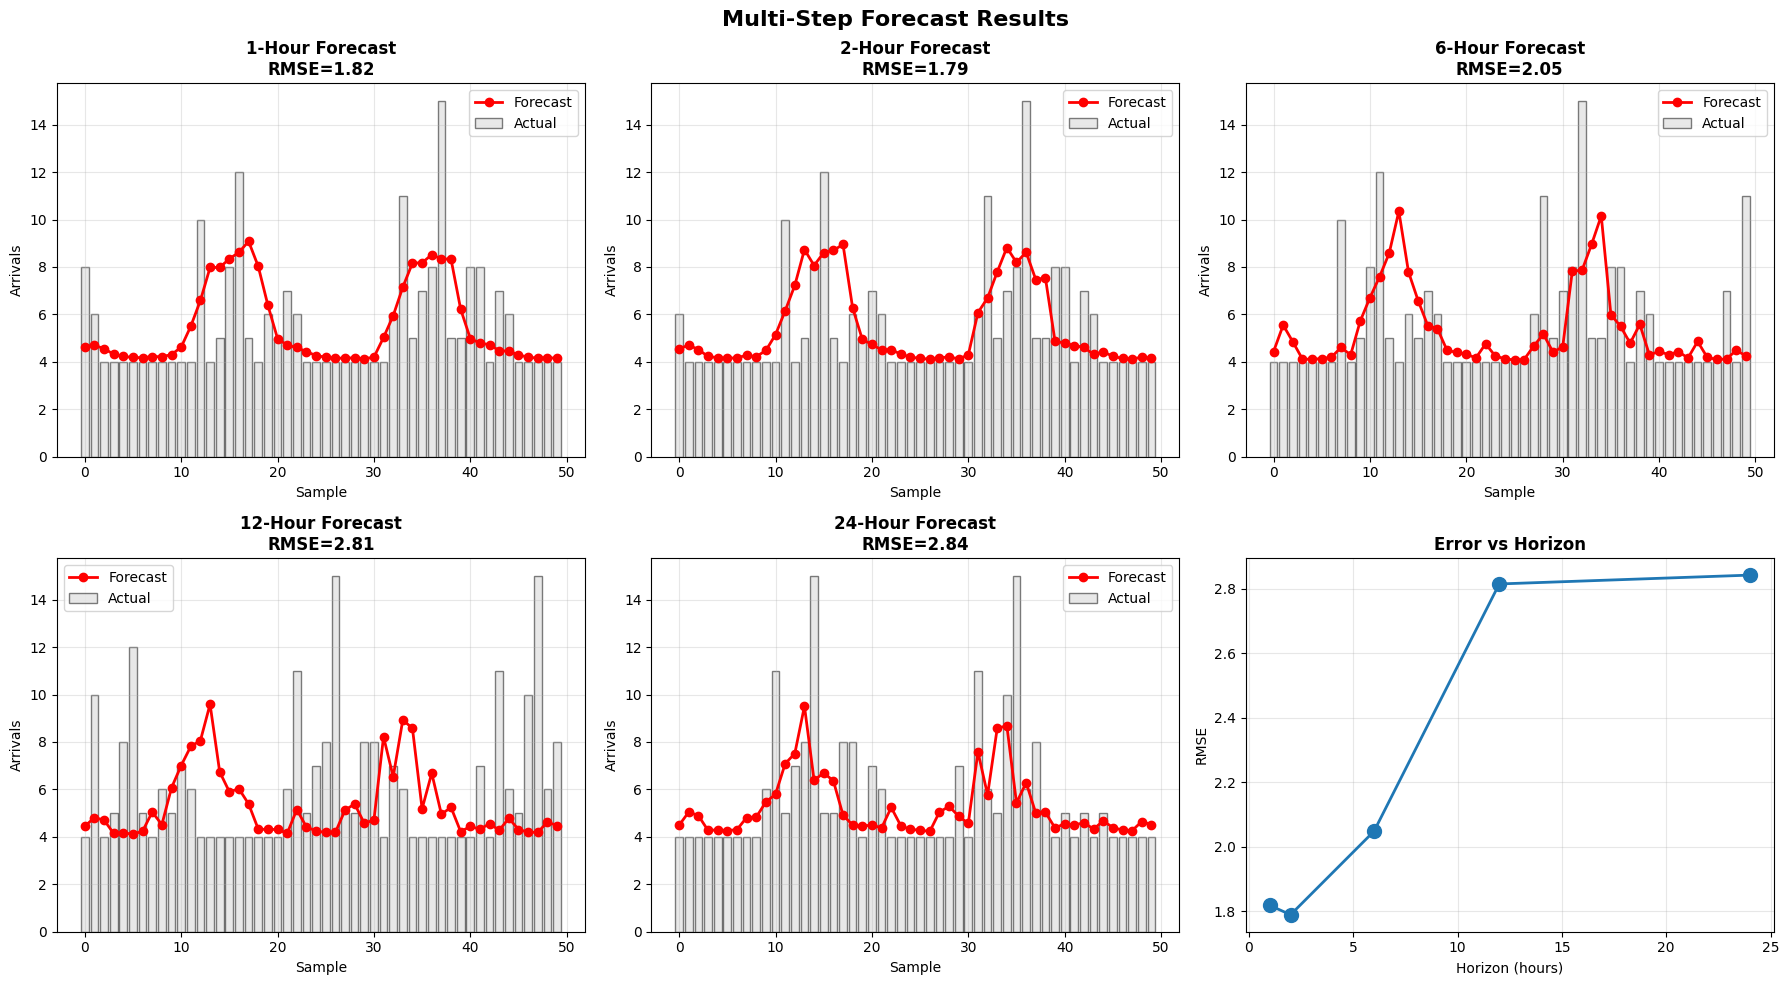

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Multi-Step Forecast Results', fontsize=16, fontweight='bold')

for idx, horizon in enumerate([1, 2, 6, 12, 24]):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]

    preds = results[horizon]['predictions'][:50]
    acts = results[horizon]['actuals'][:50]
    x = np.arange(len(preds))

    ax.bar(x, acts, alpha=0.5, label='Actual', color='lightgray', edgecolor='black')
    ax.plot(x, preds, 'o-', label='Forecast', color='red', linewidth=2)
    ax.set_title(f'{horizon}-Hour Forecast\nRMSE={results[horizon]["rmse"]:.2f}', fontweight='bold')
    ax.set_xlabel('Sample')
    ax.set_ylabel('Arrivals')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Performance degradation
ax = axes[1, 2]
horizons = sorted(results.keys())
rmses = [results[h]['rmse'] for h in horizons]
ax.plot(horizons, rmses, 'o-', linewidth=2, markersize=10)
ax.set_xlabel('Horizon (hours)')
ax.set_ylabel('RMSE')
ax.set_title('Error vs Horizon', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('forecast_visualization.png', dpi=300, bbox_inches='tight')
print(" Saved: forecast_visualization.png")
plt.show()
